# Baseline vs PhoBERT End-to-End Benchmark

Notebook này benchmark `Baseline hybrid` và `PhoBERT` trên bộ smart-home corpus hiện tại.

Các trục đánh giá chính:
- Intent classification quality
- Slot tagging quality
- Latency và model size
- Sức chống chịu với câu **không dấu**
- Hiệu quả của một tầng **diacritic restoration** đơn giản trước PhoBERT

Lưu ý kỹ thuật:
- Với PhoBERT, câu không dấu thường gây giảm chất lượng do **distribution shift** và **token fragmentation**, không phải OOV theo nghĩa word-level cổ điển.
- Tầng restoration trong notebook này là **lexicon-based restoration** sinh từ train split, đủ tốt để làm thí nghiệm robustness nhưng không phải production-grade restoration model.

## Setup

Chạy một lần nếu môi trường chưa có đủ package:

```bash
pip install -r requirements-phobert.txt
```

In [1]:
from pathlib import Path
import json
import random
import sys

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.experiments.phobert_benchmark import (
    build_restoration_lexicon,
    evaluate_baseline_intent,
    evaluate_phobert_intent,
    evaluate_phobert_slot,
    evaluate_restoration_quality,
    evaluate_slot_rule_baseline,
    intent_confusion,
    load_scenario_dataset,
    records_for_view,
    tokenizer_fragmentation,
    train_baseline_intent_model,
    train_phobert_intent,
    train_phobert_slot,
    train_slot_rule_baseline,
)

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
SCENARIOS = ['clean', 'no_diacritic', 'restored']

dataset = load_scenario_dataset()
restoration_lexicon = build_restoration_lexicon(dataset.train_records)

train_views = {scenario: records_for_view(dataset.train_records, scenario, restoration_lexicon) for scenario in SCENARIOS}
val_views = {scenario: records_for_view(dataset.val_records, scenario, restoration_lexicon) for scenario in SCENARIOS}
test_views = {scenario: records_for_view(dataset.test_records, scenario, restoration_lexicon) for scenario in SCENARIOS}

summary = {
    'dataset_name': dataset.name,
    'train_rows': len(dataset.train_records),
    'val_rows': len(dataset.val_records),
    'test_rows': len(dataset.test_records),
    'intent_labels': dataset.label_list,
    'slot_labels': dataset.slot_labels,
    'restoration_coverage_estimate': round(dataset.restoration_coverage, 4),
}
summary

{'dataset_name': 'smarthome_vi_v1',
 'train_rows': 3037,
 'val_rows': 650,
 'test_rows': 513,
 'intent_labels': ['control_device',
  'environmental_comfort',
  'greeting',
  'out_of_scope',
  'query_device_status',
  'query_sensor'],
 'slot_labels': ['B-action',
  'B-comparison',
  'B-device_name',
  'B-device_type',
  'B-room',
  'B-sensor_type',
  'I-action',
  'I-comparison',
  'I-device_name',
  'I-device_type',
  'I-room',
  'O'],
 'restoration_coverage_estimate': 0.9579}

In [3]:
restoration_quality = evaluate_restoration_quality(dataset.test_records, restoration_lexicon)
display(restoration_quality)

scenario_examples = pd.DataFrame(
    {
        'clean': [test_views['clean'][0]['text'], test_views['clean'][1]['text'], test_views['clean'][2]['text']],
        'no_diacritic': [test_views['no_diacritic'][0]['text'], test_views['no_diacritic'][1]['text'], test_views['no_diacritic'][2]['text']],
        'restored': [test_views['restored'][0]['text'], test_views['restored'][1]['text'], test_views['restored'][2]['text']],
    }
)
display(scenario_examples)

,restoration_token_accuracy,covered_vocabulary_ratio
0,0.933,0.9579


,clean,no_diacritic,restored
0,bat den phong khach,bat den phong khach,bật đèn phòng khách
1,bat den khach,bat den khach,bật đèn khách
2,bat den pk,bat den pk,bật đèn pk


## Intent Benchmark

Chiến lược đánh giá:
- Train **một** baseline model trên `clean train`
- Train **một** PhoBERT intent model trên `clean train`
- Evaluate cả hai trên `clean`, `no_diacritic`, và `restored`

Như vậy bảng metric sẽ phản ánh đúng tính **robustness** của từng hướng tiếp cận.

In [4]:
baseline_intent = train_baseline_intent_model(train_views['clean'])
baseline_intent_summaries = []
baseline_intent_reports = {}

for scenario in SCENARIOS:
    summary_df, detailed_df = evaluate_baseline_intent(baseline_intent, test_views[scenario], scenario)
    baseline_intent_summaries.append(summary_df)
    baseline_intent_reports[scenario] = detailed_df

baseline_intent_summary = pd.concat(baseline_intent_summaries, ignore_index=True)
display(baseline_intent_summary)

,model,scenario,accuracy,macro_f1,latency_ms_per_sample,model_size_mb
0,baseline_tfidf_lr,clean,0.961,0.9169,0.0323,0.085
1,baseline_tfidf_lr,no_diacritic,0.961,0.9169,0.0324,0.085
2,baseline_tfidf_lr,restored,0.961,0.9169,0.0319,0.085


In [5]:
RUN_PHOBERT_TRAINING = True
PHOBERT_EPOCHS = 2
PHOBERT_BATCH_SIZE = 8

if not RUN_PHOBERT_TRAINING:
    raise RuntimeError('Set RUN_PHOBERT_TRAINING=True to execute the PhoBERT benchmark end-to-end.')

phobert_intent = train_phobert_intent(
    train_views['clean'],
    val_views['clean'],
    epochs=PHOBERT_EPOCHS,
    batch_size=PHOBERT_BATCH_SIZE,
)
phobert_intent

Map:   0%|          | 0/3037 [00:00<?, ? examples/s]

Map:   0%|          | 0/650 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.293661,0.239770,0.909231,0.854060
2,0.012283,0.276230,0.912308,0.862757


{'trainer': <transformers.trainer.Trainer at 0x1852565d550>,
 'tokenizer': PhobertTokenizer(name_or_path='vinai/phobert-base', vocab_size=64000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
 	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	64000: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 }),
 'label_list': ['control_device',
  

In [6]:
phobert_intent_summaries = []
phobert_intent_reports = {}
phobert_intent_predictions = {}

for scenario in SCENARIOS:
    summary_df, detailed_df, preds = evaluate_phobert_intent(phobert_intent, test_views[scenario], scenario)
    phobert_intent_summaries.append(summary_df)
    phobert_intent_reports[scenario] = detailed_df
    phobert_intent_predictions[scenario] = preds

phobert_intent_summary = pd.concat(phobert_intent_summaries, ignore_index=True)
intent_compare = pd.concat([baseline_intent_summary, phobert_intent_summary], ignore_index=True)
display(intent_compare.sort_values(['model', 'scenario']).reset_index(drop=True))

Map:   0%|          | 0/513 [00:00<?, ? examples/s]

Map:   0%|          | 0/513 [00:00<?, ? examples/s]

C:\Users\ACER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ACER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ACER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Map:   0%|          | 0/513 [00:00<?, ? examples/s]

,model,scenario,accuracy,macro_f1,latency_ms_per_sample,model_size_mb
0,baseline_tfidf_lr,clean,0.9610,0.9169,0.0323,0.085
1,baseline_tfidf_lr,no_diacritic,0.9610,0.9169,0.0324,0.085
2,baseline_tfidf_lr,restored,0.9610,0.9169,0.0319,0.085
3,phobert_intent,clean,0.9552,0.8991,2.3928,514.995
4,phobert_intent,no_diacritic,0.7641,0.5177,2.5458,514.995
5,phobert_intent,restored,0.9610,0.9169,2.3250,514.995


In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('vinai/phobert-base')
fragmentation_examples = [
    test_views['clean'][0]['text'],
    test_views['no_diacritic'][0]['text'],
    test_views['restored'][0]['text'],
    test_views['clean'][25]['text'],
    test_views['no_diacritic'][25]['text'],
]
display(tokenizer_fragmentation(tokenizer, fragmentation_examples))

,text,pieces,piece_count,unk_count
0,bat den phong khach,"[bat, den, phong, kha@@, ch]",5,0
1,bat den phong khach,"[bat, den, phong, kha@@, ch]",5,0
2,bật đèn phòng khách,"[bật, đèn, phòng, khách]",4,0
3,bật cho đèn khách được không,"[bật, cho, đèn, khách, được, không]",6,0
4,bat cho den khach duoc khong,"[bat, cho, den, kha@@, ch, du@@, oc, kh@@, ong]",9,0


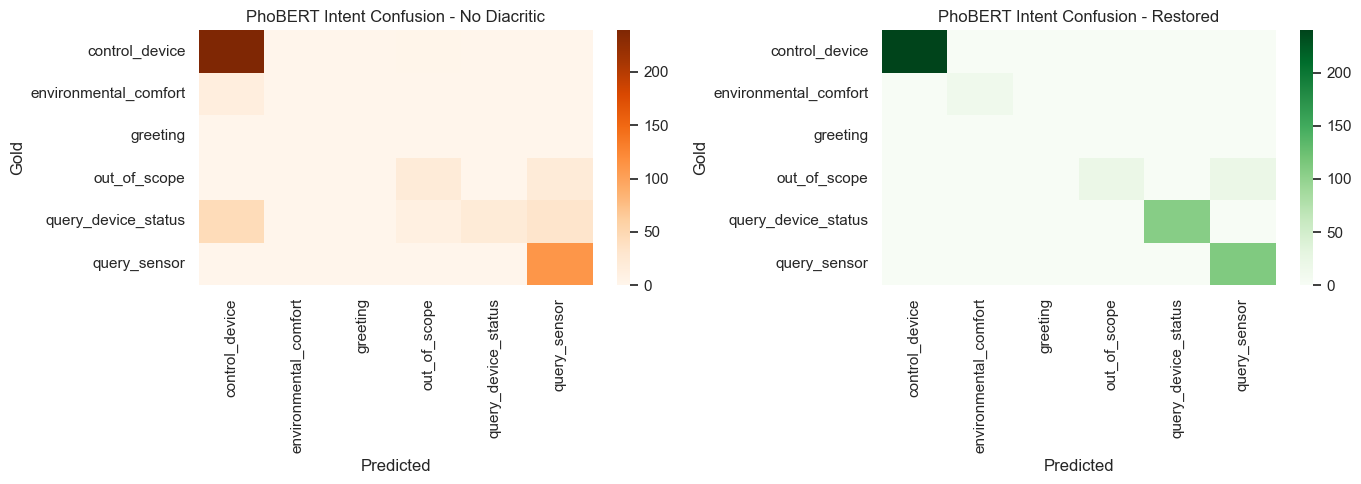

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_no_diacritic = intent_confusion(test_views['no_diacritic'], phobert_intent_predictions['no_diacritic'], dataset.label_list)
cm_restored = intent_confusion(test_views['restored'], phobert_intent_predictions['restored'], dataset.label_list)

sns.heatmap(cm_no_diacritic, annot=False, cmap='Oranges', ax=axes[0])
axes[0].set_title('PhoBERT Intent Confusion - No Diacritic')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Gold')

sns.heatmap(cm_restored, annot=False, cmap='Greens', ax=axes[1])
axes[1].set_title('PhoBERT Intent Confusion - Restored')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Gold')

plt.tight_layout()
plt.show()

## Slot Benchmark

Ở đây mình so sánh:
- `baseline_rule_slots`: rule/phrase lexicon từ train split
- `phobert_slot`: token classification fine-tune trên cùng clean split

Slot metrics chính:
- `slot_f1`
- `exact_match`
- `latency_ms_per_sample`
- `model_size_mb`

In [9]:
baseline_slot = train_slot_rule_baseline(train_views['clean'])
baseline_slot_summaries = []
baseline_slot_reports = {}

for scenario in SCENARIOS:
    summary_df, detailed_df = evaluate_slot_rule_baseline(baseline_slot, test_views[scenario], scenario)
    baseline_slot_summaries.append(summary_df)
    baseline_slot_reports[scenario] = detailed_df

baseline_slot_summary = pd.concat(baseline_slot_summaries, ignore_index=True)
display(baseline_slot_summary)

,model,scenario,slot_f1,exact_match,latency_ms_per_sample,model_size_mb
0,baseline_rule_slots,clean,0.7493,0.4776,0.0275,0.003
1,baseline_rule_slots,no_diacritic,0.7493,0.4776,0.0255,0.003
2,baseline_rule_slots,restored,0.7493,0.4776,0.0267,0.003


In [10]:
phobert_slot = train_phobert_slot(
    train_views['clean'],
    val_views['clean'],
    epochs=PHOBERT_EPOCHS,
    batch_size=PHOBERT_BATCH_SIZE,
)
phobert_slot

Map:   0%|          | 0/3037 [00:00<?, ? examples/s]

Map:   0%|          | 0/650 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Slot F1,Slot Precision,Slot Recall
1,0.353125,0.103401,0.964859,0.956219,0.973658
2,0.040888,0.118322,0.947932,0.911985,0.986829


C:\Users\ACER\AppData\Local\Programs\Python\Python314\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'trainer': <transformers.trainer.Trainer at 0x185e6e9cec0>,
 'tokenizer': PhobertTokenizer(name_or_path='vinai/phobert-base', vocab_size=64000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
 	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	64000: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 }),
 'label_list': ['B-action',
  'B-com

In [11]:
phobert_slot_summaries = []
phobert_slot_reports = {}

for scenario in SCENARIOS:
    summary_df, detailed_df = evaluate_phobert_slot(phobert_slot, test_views[scenario], scenario)
    phobert_slot_summaries.append(summary_df)
    phobert_slot_reports[scenario] = detailed_df

phobert_slot_summary = pd.concat(phobert_slot_summaries, ignore_index=True)
slot_compare = pd.concat([baseline_slot_summary, phobert_slot_summary], ignore_index=True)
display(slot_compare.sort_values(['model', 'scenario']).reset_index(drop=True))

Map:   0%|          | 0/513 [00:00<?, ? examples/s]

Map:   0%|          | 0/513 [00:00<?, ? examples/s]

C:\Users\ACER\AppData\Local\Programs\Python\Python314\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Map:   0%|          | 0/513 [00:00<?, ? examples/s]

,model,scenario,slot_f1,exact_match,latency_ms_per_sample,model_size_mb
0,baseline_rule_slots,clean,0.7493,0.4776,0.0275,0.003
1,baseline_rule_slots,no_diacritic,0.7493,0.4776,0.0255,0.003
2,baseline_rule_slots,restored,0.7493,0.4776,0.0267,0.003
3,phobert_slot,clean,0.9661,0.9630,2.4297,512.760
4,phobert_slot,no_diacritic,0.3210,0.2398,2.6436,512.760
5,phobert_slot,restored,0.9855,0.9825,2.3386,512.760


## Final Comparison Tables

Đây là hai bảng metric chính có thể đưa thẳng vào báo cáo hoặc slide bảo vệ.

In [12]:
intent_compare = intent_compare.sort_values(['scenario', 'model']).reset_index(drop=True)
slot_compare = slot_compare.sort_values(['scenario', 'model']).reset_index(drop=True)

display(intent_compare)
display(slot_compare)
display(restoration_quality)

,model,scenario,accuracy,macro_f1,latency_ms_per_sample,model_size_mb
0,baseline_tfidf_lr,clean,0.9610,0.9169,0.0323,0.085
1,phobert_intent,clean,0.9552,0.8991,2.3928,514.995
2,baseline_tfidf_lr,no_diacritic,0.9610,0.9169,0.0324,0.085
3,phobert_intent,no_diacritic,0.7641,0.5177,2.5458,514.995
4,baseline_tfidf_lr,restored,0.9610,0.9169,0.0319,0.085
5,phobert_intent,restored,0.9610,0.9169,2.3250,514.995


,model,scenario,slot_f1,exact_match,latency_ms_per_sample,model_size_mb
0,baseline_rule_slots,clean,0.7493,0.4776,0.0275,0.003
1,phobert_slot,clean,0.9661,0.9630,2.4297,512.760
2,baseline_rule_slots,no_diacritic,0.7493,0.4776,0.0255,0.003
3,phobert_slot,no_diacritic,0.3210,0.2398,2.6436,512.760
4,baseline_rule_slots,restored,0.7493,0.4776,0.0267,0.003
5,phobert_slot,restored,0.9855,0.9825,2.3386,512.760


,restoration_token_accuracy,covered_vocabulary_ratio
0,0.933,0.9579


## Suggested Interpretation

Kỳ vọng khi đọc kết quả:
- `Baseline` thường khá ổn với `no_diacritic` vì toàn bộ pipeline đã normalize về không dấu.
- `PhoBERT clean` thường mạnh hơn trên dữ liệu tiếng Việt chuẩn.
- `PhoBERT no_diacritic` thường giảm rõ vì mất tín hiệu dấu và token fragmentation tăng.
- `PhoBERT restored` nếu kéo lại metric đáng kể thì đây là bằng chứng tốt rằng tầng restoration trước transformer có giá trị thực sự.

Nếu cần đào sâu hơn, bạn có thể mở các bảng `baseline_intent_reports`, `phobert_intent_reports`, `baseline_slot_reports`, `phobert_slot_reports` để xem per-class breakdown.